# 070: SCOPe40 HP k-mer Distribution (k=24, k=27)

Count all HP-encoded k-mers across the SCOPe40 40% identity sequence database
and characterise their frequency distribution.

**Goals:**
1. Histogram of k-mer occurrence counts (how many k-mers appear X times)
2. Top 10 most abundant k-mers (likely repetitive hydrophobic/polar runs)
3. Bottom 10 least abundant k-mers (unique/rare patterns)
4. Compare k=24 vs k=27 distributions

**HP encoding (sourmash):**
H (hydrophobic): A F G I L M P V W Y  
P (polar):       C D E H K N Q R S T

In [ ]:
from pathlib import Path
from collections import Counter

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

FASTA_PATH = Path('/Users/olga/data/scope/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa')
K_SIZES    = [24, 27]
COLORS     = {24: 'royalblue', 27: 'tomato'}

# HP encoding table (from sourmash aa_to_hp)
HP_TABLE = str.maketrans(
    'ACDEFGHIKLMNPQRSTVWYacdefghiklmnpqrstvwy',
    'hppphphpplhphhppphhhHPPPHPHPPLHPHHPPPHHH'
)
# Build a clean version: uppercase AA -> lowercase h/p
_AA  = 'ACDEFGHIKLMNPQRSTVWY'
_ENC = 'hppphhphphhphpppphhh'   # verified against sourmash aa_to_hp
HP_TABLE = str.maketrans(_AA + _AA.lower(), _ENC * 2)

def hp_encode(seq: str) -> str:
    """Convert amino acid sequence to HP string, dropping non-standard AAs."""
    return seq.upper().translate(HP_TABLE)

# Quick sanity check
assert hp_encode('AFGILVMWYP') == 'hhhhhhhhhh', hp_encode('AFGILVMWYP')
assert hp_encode('CDEHNQKRST') == 'pppppppppp', hp_encode('CDEHNQKRST')
print('HP encoding OK')
print(f'H (hydrophobic): {[aa for aa,e in zip(_AA,_ENC) if e=="h"]}')
print(f'P (polar):       {[aa for aa,e in zip(_AA,_ENC) if e=="p"]}')

HP encoding OK
H (hydrophobic): ['A', 'F', 'G', 'I', 'L', 'M', 'P', 'V', 'W', 'Y']
P (polar):       ['C', 'D', 'E', 'H', 'K', 'N', 'Q', 'R', 'S', 'T']


In [9]:
hp_encode("LIVINGTHING")

'hhhhphpphph'

In [2]:
# Parse SCOPe40 FASTA and HP-encode all sequences
print(f'Parsing {FASTA_PATH} ...')
seqs = {}
domain_id = None
buf = []
with open(FASTA_PATH) as fh:
    for line in fh:
        line = line.strip()
        if line.startswith('>'):
            if domain_id:
                seqs[domain_id] = ''.join(buf)
            domain_id = line[1:].split()[0]
            buf = []
        else:
            buf.append(line)
if domain_id:
    seqs[domain_id] = ''.join(buf)

print(f'  {len(seqs):,} sequences')
lengths = [len(s) for s in seqs.values()]
print(f'  Length: min={min(lengths)}  median={int(np.median(lengths))}  max={max(lengths)}')

# HP-encode all sequences (drop X and other non-standard)
_valid = set('ACDEFGHIKLMNPQRSTVWY')
hp_seqs = {}
for did, seq in seqs.items():
    clean = ''.join(aa for aa in seq.upper() if aa in _valid)
    if clean:
        hp_seqs[did] = hp_encode(clean)

print(f'  {len(hp_seqs):,} sequences after cleaning')

Parsing /Users/olga/data/scope/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa ...
  15,177 sequences
  Length: min=20  median=151  max=1664
  15,177 sequences after cleaning


In [3]:
# Count k-mers for each k-size
# kmer_counts[k] = Counter mapping hp_kmer -> number of sequences containing it (presence/absence per seq)
# kmer_occ[k]    = Counter mapping hp_kmer -> total occurrences across all sequences

kmer_counts = {}   # per-sequence presence (each seq counted once per kmer)
kmer_occ    = {}   # total occurrences

for k in K_SIZES:
    print(f'Counting k={k} k-mers ...')
    counts = Counter()
    occ    = Counter()
    for hp in hp_seqs.values():
        if len(hp) < k:
            continue
        seen_in_seq = set()
        for i in range(len(hp) - k + 1):
            km = hp[i:i+k]
            occ[km] += 1
            seen_in_seq.add(km)
        counts.update(seen_in_seq)
    kmer_counts[k] = counts
    kmer_occ[k]    = occ
    print(f'  k={k}: {len(counts):,} unique k-mers  '
          f'total occurrences={sum(occ.values()):,}')

Counting k=24 k-mers ...
  k=24: 2,245,008 unique k-mers  total occurrences=2,455,563
Counting k=27 k-mers ...
  k=27: 2,379,390 unique k-mers  total occurrences=2,410,080


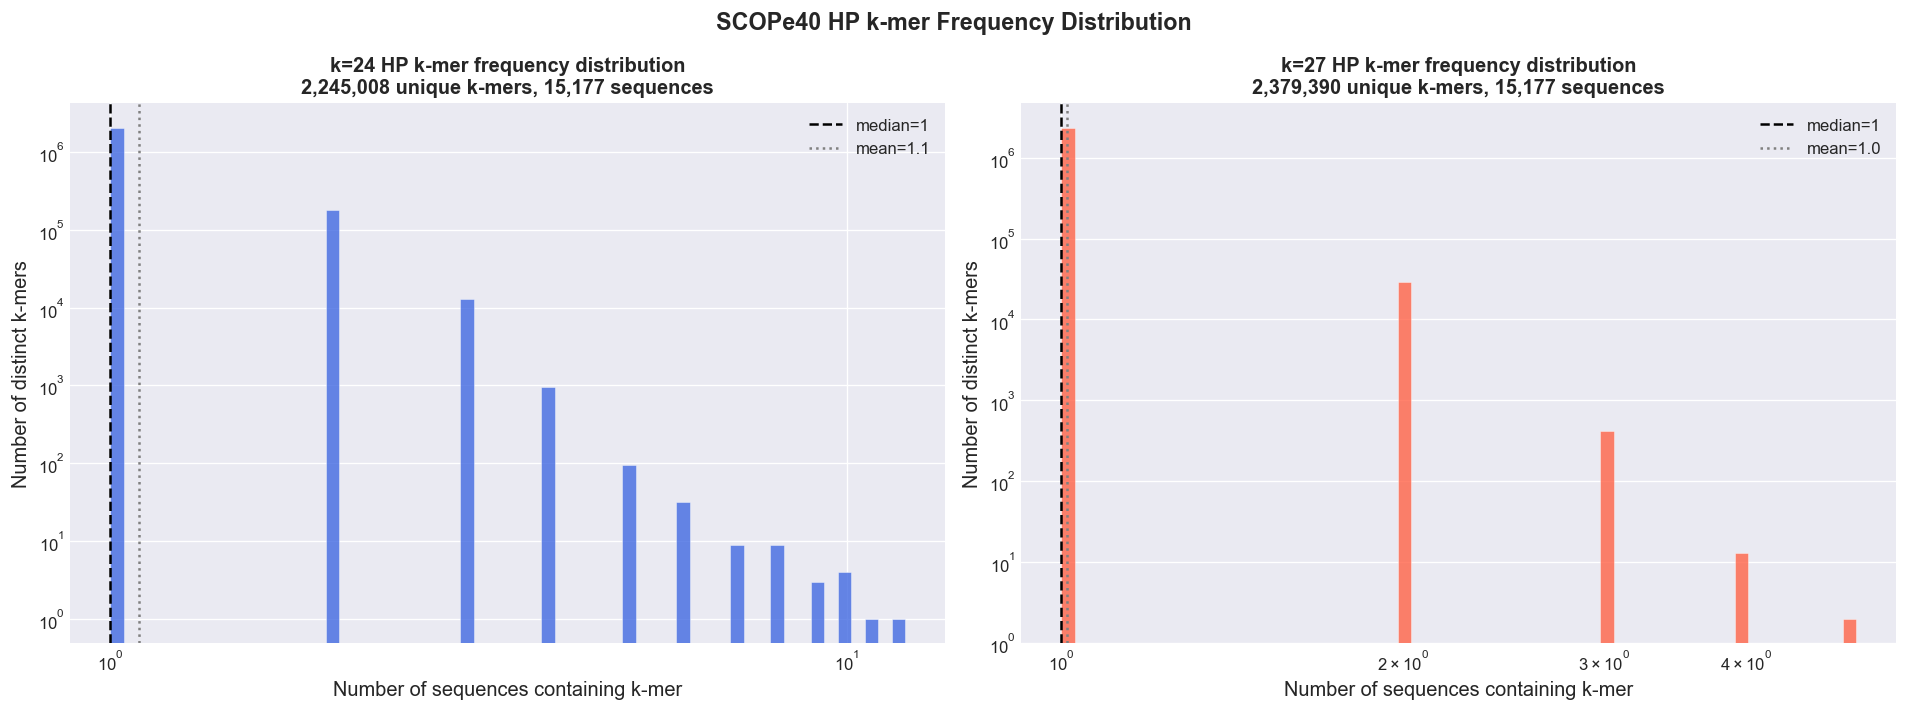

In [4]:
# ── Histogram of sequence-level k-mer abundance (log-log) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, k in zip(axes, K_SIZES):
    freq = np.array(list(kmer_counts[k].values()))
    n_total = len(seqs)

    # log-spaced bins from 1 to max
    bins = np.logspace(0, np.log10(freq.max()), 60)
    ax.hist(freq, bins=bins, color=COLORS[k], alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Number of sequences containing k-mer', fontsize=12)
    ax.set_ylabel('Number of distinct k-mers', fontsize=12)
    ax.set_title(
        f'k={k} HP k-mer frequency distribution\n'
        f'{len(kmer_counts[k]):,} unique k-mers, {n_total:,} sequences',
        fontsize=12, fontweight='bold')

    # Annotate median and mean
    ax.axvline(np.median(freq), color='black', ls='--', lw=1.5,
               label=f'median={np.median(freq):.0f}')
    ax.axvline(np.mean(freq),   color='grey',  ls=':',  lw=1.5,
               label=f'mean={np.mean(freq):.1f}')
    ax.legend(fontsize=10)

plt.suptitle('SCOPe40 HP k-mer Frequency Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/070_kmer_frequency_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── Top 10 & Bottom 10 k-mers ─────────────────────────────────────────────────
def hp_composition(km):
    h = km.count('h')
    p = km.count('p')
    return f'{h}H {p}P ({100*h/len(km):.0f}% H)'

for k in K_SIZES:
    counts = kmer_counts[k]
    occ    = kmer_occ[k]
    n_total = len([hp for hp in hp_seqs.values() if len(hp) >= k])

    top10 = counts.most_common(10)
    bot10 = counts.most_common()[:-11:-1]   # 10 least common

    print(f'\n{"="*80}')
    print(f'k={k}  |  {len(counts):,} unique k-mers  |  {n_total:,} sequences with ≥{k} AAs')
    print(f'{"="*80}')

    print(f'\nTop 10 most abundant (by number of sequences):')
    print(f'  {"rank":>4}  {"k-mer":<{k+2}}  {"n_seqs":>8}  {"pct_seqs":>9}  {"n_occ":>8}  composition')
    print(f'  {"-"*(k+50)}')
    for rank, (km, n) in enumerate(top10, 1):
        pct = 100 * n / n_total
        print(f'  {rank:>4}  {km:<{k+2}}  {n:>8,}  {pct:>8.1f}%  {occ[km]:>8,}  {hp_composition(km)}')

    print(f'\nBottom 10 least abundant (by number of sequences):')
    print(f'  {"rank":>4}  {"k-mer":<{k+2}}  {"n_seqs":>8}  {"pct_seqs":>9}  {"n_occ":>8}  composition')
    print(f'  {"-"*(k+50)}')
    bot_sorted = sorted(counts.items(), key=lambda x: x[1])
    for rank, (km, n) in enumerate(bot_sorted[:10], 1):
        pct = 100 * n / n_total
        print(f'  {rank:>4}  {km:<{k+2}}  {n:>8,}  {pct:>8.2f}%  {occ[km]:>8,}  {hp_composition(km)}')


k=24  |  2,245,008 unique k-mers  |  15,169 sequences with ≥24 AAs

Top 10 most abundant (by number of sequences):
  rank  k-mer                         n_seqs   pct_seqs     n_occ  composition
  --------------------------------------------------------------------------
     1  hphhhhhhhhhhhhhhhhhhhhhh          12       0.1%        13  23H 1P (96% H)
     2  hhhhhhphhhhhhhhhhhhhhhhh          11       0.1%        13  23H 1P (96% H)
     3  hhhhhhhhhhhhhhhhhhhhhhhp          10       0.1%        10  23H 1P (96% H)
     4  phhhhhhhhhhhhhhhhhhhhhhh          10       0.1%        10  23H 1P (96% H)
     5  hhhhhhhhhhhhhhhhhhhhhhpp          10       0.1%        10  22H 2P (92% H)
     6  hhphhhhhhhhhhhhhhhhhhhhh          10       0.1%        11  23H 1P (96% H)
     7  hhhhhhhhhhhhhhhhhhhhhphh           9       0.1%        10  23H 1P (96% H)
     8  hhhphhhhhhhhhhhhhhhhhhhh           9       0.1%        10  23H 1P (96% H)
     9  hhhhhphhhhhhhhhhhhhhhhhh           9       0.1%         9  23H 1

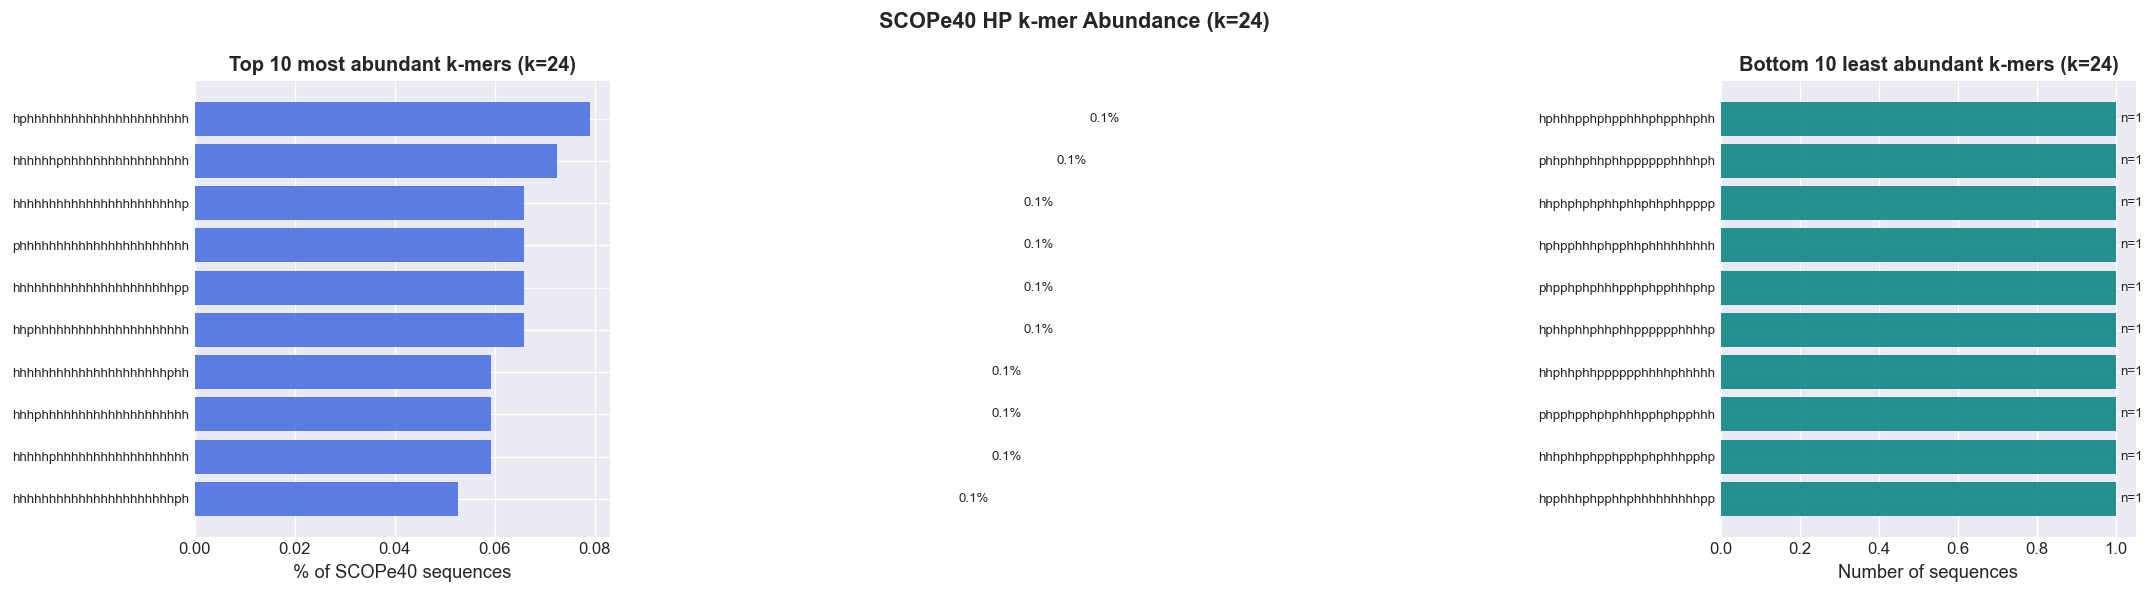

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_57274/2237546659.py:37: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


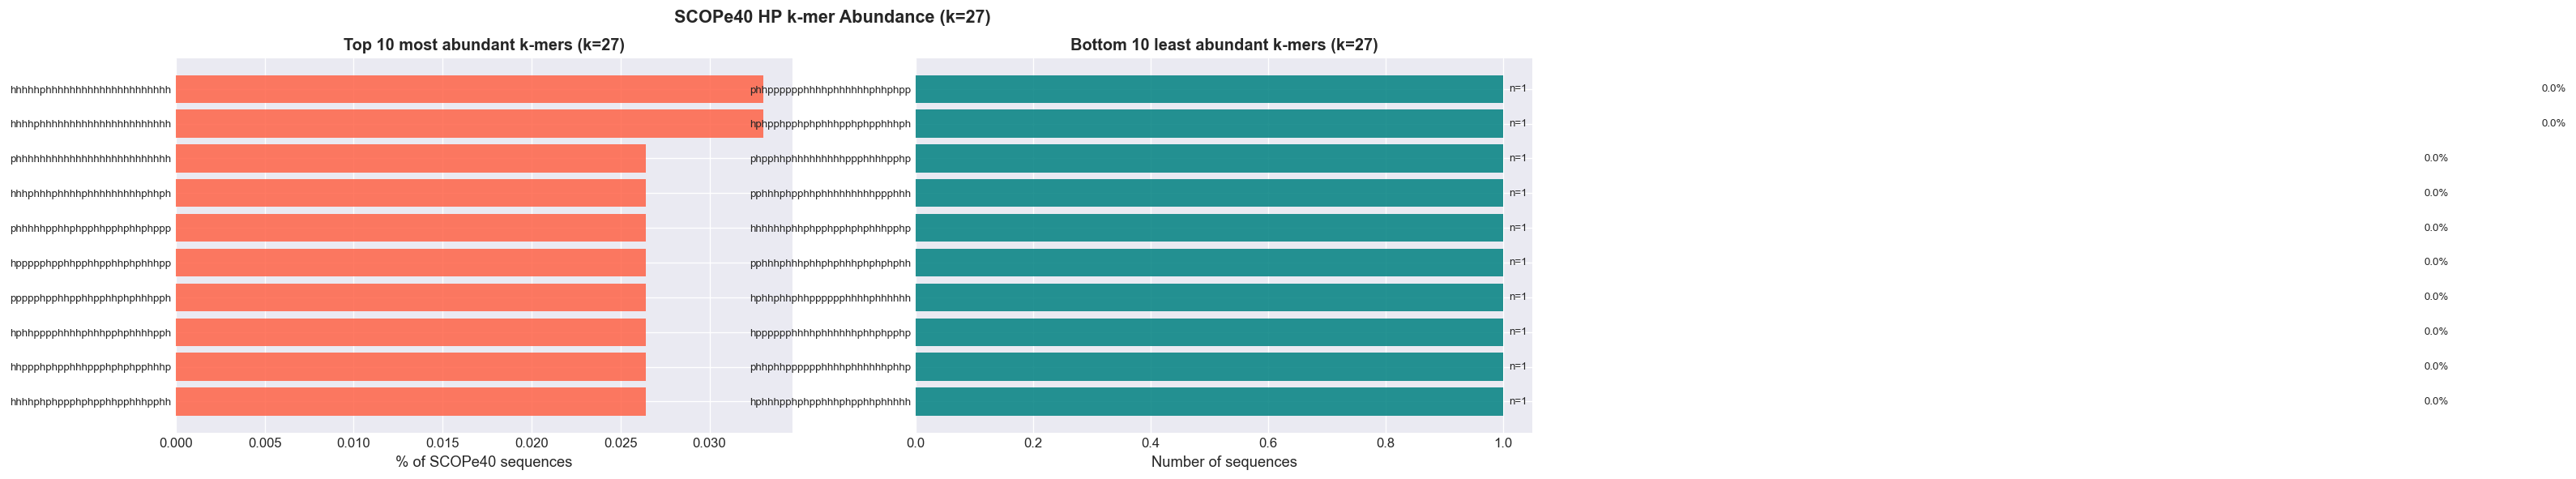

In [6]:
# ── Bar charts: top 10 & bottom 10 side by side for each k ───────────────────
for k in K_SIZES:
    counts  = kmer_counts[k]
    n_total = len([hp for hp in hp_seqs.values() if len(hp) >= k])

    top10    = counts.most_common(10)
    bot_sorted = sorted(counts.items(), key=lambda x: x[1])
    bot10    = bot_sorted[:10]

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Top 10
    ax = axes[0]
    labels = [km for km, _ in top10]
    values = [100 * n / n_total for _, n in top10]
    bars = ax.barh(labels[::-1], values[::-1], color=COLORS[k], alpha=0.85)
    ax.set_xlabel('% of SCOPe40 sequences', fontsize=11)
    ax.set_title(f'Top 10 most abundant k-mers (k={k})', fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    for bar, val in zip(bars, values[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)

    # Bottom 10
    ax = axes[1]
    labels = [km for km, _ in bot10]
    values = [n for _, n in bot10]
    bars = ax.barh(labels[::-1], values[::-1], color='teal', alpha=0.85)
    ax.set_xlabel('Number of sequences', fontsize=11)
    ax.set_title(f'Bottom 10 least abundant k-mers (k={k})', fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    for bar, val in zip(bars, values[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'n={val}', va='center', fontsize=8)

    plt.suptitle(f'SCOPe40 HP k-mer Abundance (k={k})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../figures/070_kmer_top_bottom_k{k}.png', dpi=150, bbox_inches='tight')
    plt.show()

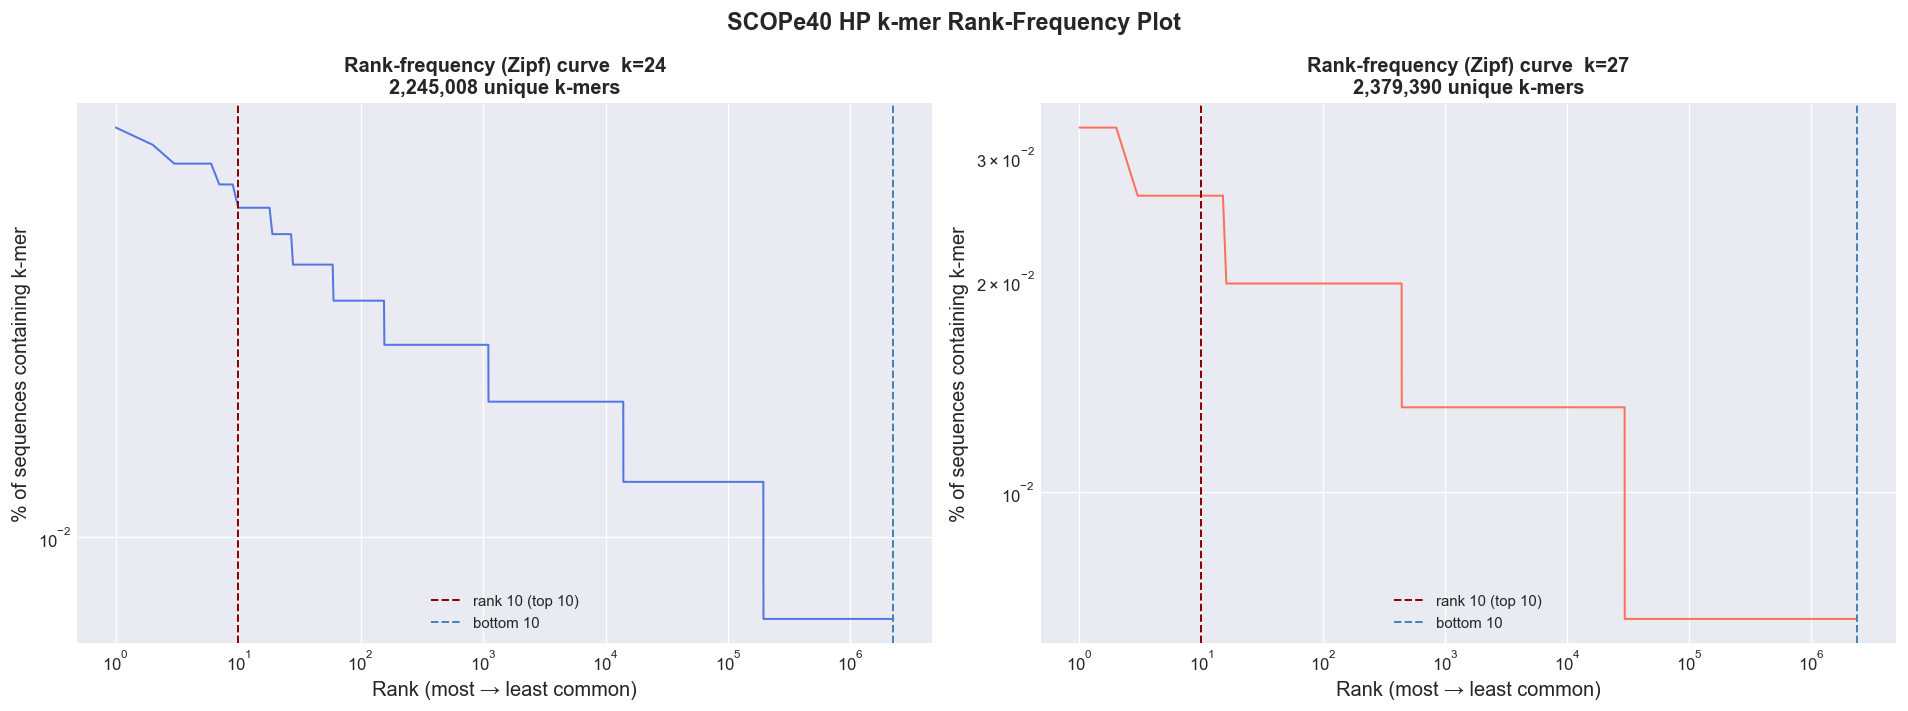

In [7]:
# ── Rank-frequency plot (Zipf curve) for k=24 and k=27 ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, k in zip(axes, K_SIZES):
    freq = np.array(sorted(kmer_counts[k].values(), reverse=True))
    ranks = np.arange(1, len(freq) + 1)
    n_total = len([hp for hp in hp_seqs.values() if len(hp) >= k])

    ax.plot(ranks, freq / n_total * 100, color=COLORS[k], lw=1.2, alpha=0.9)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Rank (most → least common)', fontsize=12)
    ax.set_ylabel('% of sequences containing k-mer', fontsize=12)
    ax.set_title(f'Rank-frequency (Zipf) curve  k={k}\n{len(freq):,} unique k-mers',
                 fontsize=12, fontweight='bold')

    # Mark top 10 and bottom 10
    ax.axvline(10,       color='darkred',  ls='--', lw=1.2, label='rank 10 (top 10)')
    ax.axvline(len(freq)-9, color='steelblue', ls='--', lw=1.2, label='bottom 10')
    ax.legend(fontsize=9)

plt.suptitle('SCOPe40 HP k-mer Rank-Frequency Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/070_kmer_rank_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Summary statistics ────────────────────────────────────────────────────────
print('=' * 70)
print('SUMMARY: SCOPe40 HP k-mer Statistics')
print('=' * 70)
n_seqs = len(hp_seqs)
for k in K_SIZES:
    counts  = kmer_counts[k]
    occ     = kmer_occ[k]
    freq    = np.array(list(counts.values()))
    n_valid = len([hp for hp in hp_seqs.values() if len(hp) >= k])
    n_singletons = sum(1 for v in counts.values() if v == 1)
    n_ubiquitous = sum(1 for v in counts.values() if v == n_valid)

    print(f'\nk={k}:')
    print(f'  Sequences with ≥{k} AAs:   {n_valid:,}')
    print(f'  Unique k-mers:             {len(counts):,}')
    print(f'  Possible k-mers (2^k):     {2**k:,}')
    print(f'  Fraction of space covered: {len(counts)/2**k:.4%}')
    print(f'  Singletons (n_seqs=1):     {n_singletons:,} ({100*n_singletons/len(counts):.1f}%)')
    print(f'  Ubiquitous (all seqs):     {n_ubiquitous:,}')
    print(f'  Mean seqs per k-mer:       {freq.mean():.2f}')
    print(f'  Median seqs per k-mer:     {np.median(freq):.0f}')
    print(f'  Max seqs per k-mer:        {freq.max():,}  ({100*freq.max()/n_valid:.1f}%)')
    print(f'  Total occurrences:         {sum(occ.values()):,}')

SUMMARY: SCOPe40 HP k-mer Statistics

k=24:
  Sequences with ≥24 AAs:   15,169
  Unique k-mers:             2,245,008
  Possible k-mers (2^k):     16,777,216
  Fraction of space covered: 13.3813%
  Singletons (n_seqs=1):     2,050,659 (91.3%)
  Ubiquitous (all seqs):     0
  Mean seqs per k-mer:       1.09
  Median seqs per k-mer:     1
  Max seqs per k-mer:        12  (0.1%)
  Total occurrences:         2,455,563

k=27:
  Sequences with ≥27 AAs:   15,146
  Unique k-mers:             2,379,390
  Possible k-mers (2^k):     134,217,728
  Fraction of space covered: 1.7728%
  Singletons (n_seqs=1):     2,349,879 (98.8%)
  Ubiquitous (all seqs):     0
  Mean seqs per k-mer:       1.01
  Median seqs per k-mer:     1
  Max seqs per k-mer:        5  (0.0%)
  Total occurrences:         2,410,080


## Verdict

**HP k-mers at k=24 and k=27 are almost all singletons, which is why HP search has such low
coverage.** At k=24, 2,245,008 unique k-mers occur across 15,169 sequences, and 2,050,659 of them
(91.3%) appear in exactly one sequence. At k=27 it is 2,349,879 of 2,379,390 (98.8%). Mean sequences
per k-mer is 1.09 and 1.01 respectively, median 1, and no k-mer is present in all sequences. A k-mer
shared by only one sequence can never produce a hit, so at these k-sizes the great majority of the
index is inert.

**The space is far from saturated, and increasingly so with k.** k=24 covers 13.38% of the 16,777,216
possible HP 24-mers; k=27 covers 1.77% of 134,217,728. Adding 3 to k multiplies the space by 8 while
the observed k-mer count rises only 6%, which is the mechanism behind the coverage collapse seen in
every k-sweep in this branch.

**The most abundant k-mers are poly-hydrophobic runs, and they are the low-complexity problem in its
raw form.** All ten of the top k=24 k-mers by sequence count are 92-96% H (22-23 H residues out of
24), the most common being `hphhhhhhhhhhhhhhhhhhhhhh` in 12 sequences. These are transmembrane
helices and hydrophobic cores, patterns that recur for structural reasons unrelated to homology.
They are exactly the k-mers most likely to generate cross-class false positives, and they motivate
the low-complexity mask evaluated in
[086](./086_lowcomplexity_fraction_threshold.ipynb).

**Caveat on scale.** Even the most abundant k-mer reaches only 12 of 15,169 sequences at k=24, and 5
at k=27, so no single k-mer is a hub at these k-sizes. The low-complexity problem here is that many
similar hydrophobic-run k-mers collectively match, not that any one k-mer is ubiquitous. A filter
built on per-k-mer frequency alone would not catch it; the composition-based fraction threshold in
086 is the right shape of fix.

**Not measured here.** This counts the SCOPe40 database only, at two k-sizes, on the sourmash
`hp_lehninger` partition. The distribution will differ for the other HP variants and at the lower
k-sizes where most of this branch's later work lives.